<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/Kmeans_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Categorising countries

### Data Source

The data used in this task was orginally sourced from Help.NGO. This international non-governmental organisation specialises in emergency response, preparedness, and risk mitigation.  

### Dataset Attributes
- country: name of the country
- child_mort: death of children under 5 years of age per 1000 live births
- exports: exports of goods and services per capita. Given as a percentage of the GDP per capita
- health: total health spending per capita. Given as a percentage of GDP per capita
- imports: imports of goods and services per capita. Given as a percentage of the GDP per capita
- income: net income per person
- inflation: the measurement of the annual growth rate of the Total GDP
- life_expec: the average number of years a new born child would live if the current mortality patterns remain the same
- total_fer: the number of children that would be born to each woman if the current age-fertility rates remains the same
- gdpp: the GDP per capita. Calculated as the Total GDP divided by the total population.

## Objective  
To group countries using socio-economic and health factors to determine the development status of the country.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Random state seed
rseed = 42

## Load and explore data

In [7]:
# Import the dataset

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Country-data.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
# Check the shape

In [ ]:
# Check datatypes & counts

In [ ]:
# Get descriptive statistics

In [ ]:
# Identify any missing data

## Preprocessing and Feature Selection

In [8]:
# Drop any non-numeric features (columns)

df = df.drop(['country'], axis=1)

In [ ]:
# Create a correlation map of features to explore relationships between features
# Hint: Explore seaborn heatmap

In [ ]:
# Explore the continuous independent features against child_mort using scatter plots.

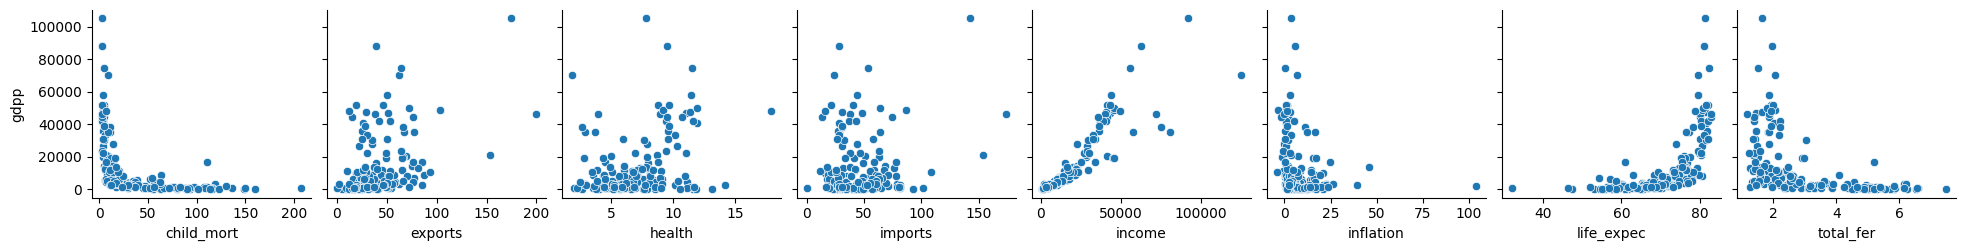

In [9]:
# Explore the continuous independent features against gdpp using scatter plots.

sns.pairplot(df, x_vars=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer'], y_vars=['gdpp'], kind='scatter')
plt.show()

In [ ]:
# Create a pair plot
# Hint: Explore seaborn pairplot

Note the peaks in the diagonal graphs that are distinct from each other or only overlap slightly. Looking at the scatter plot distributions may also give you some indication of features that would be good candidates for clustering the data.

### Scaling the Data

In [10]:
# Normalise the data using MinMaxScaler
# Name the normalised dataframe "df_scaled"

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


## K-Means Clustering

### Selecting K

In [13]:
# Plot elbow curve
def eval_Kmeans(x, k, r):
    kmeans = KMeans(n_clusters=k, random_state=r, max_iter=500)
    kmeans.fit(x)
    return kmeans.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k+1)]
    plt.plot(range(1, 11), within_cluster_vars,marker='o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

    # Plot elbow curve using scaled dataset

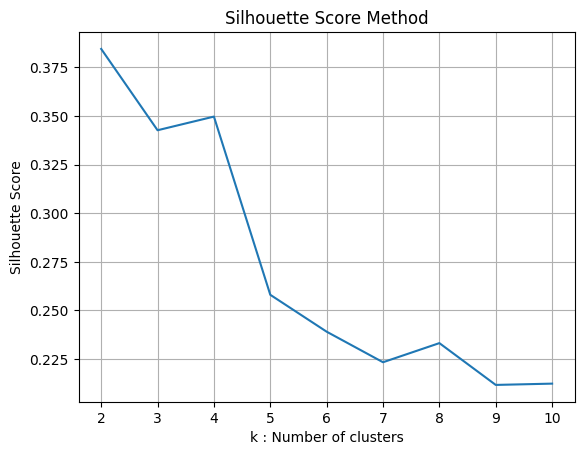

In [12]:
# Silhouette score method
kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(df_scaled, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('k : Number of clusters')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()

Based on the elbow and silhouette score method choose a value for K.

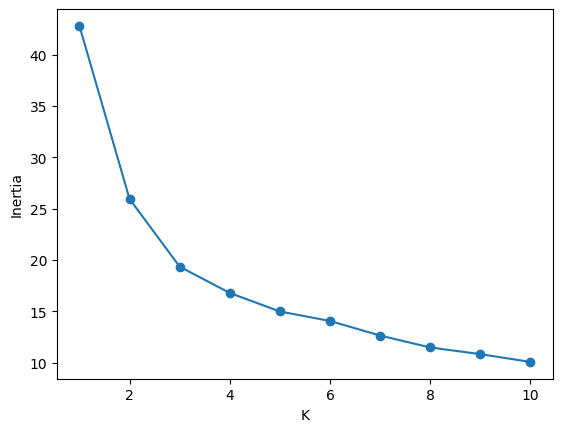

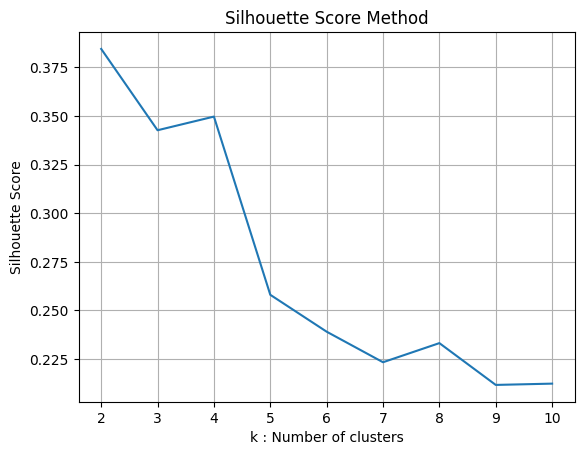

In [15]:
# Finding the optimal number of clusters using the elbow and silhouette score method.

# Elbow method

elbow_Kmeans(df_scaled, max_k=10, r=rseed)

# Silhouette score method

kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(df_scaled, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('k : Number of clusters')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()

## Fitting a K-Means Model with the selected K value

In [16]:
# Remember to set the random_state to rseed

# Fitting the scaled dataset to the optimal number of clusters.

# Setting the optimal number of clusters.

k = 3

# Fitting the model.

kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
kmeans.fit(df_scaled)

# Calculating  the silhouette score.

sil_score = silhouette_score(df_scaled, kmeans.labels_, metric='euclidean')

# Printing the silhouette score.

print(f"Silhouette score for k={k}: {sil_score}")

Silhouette score for k=3: 0.34265474105126204


In [ ]:
# Count the number of records in each cluster

In [ ]:
# Check model performance with the silhouette coefficient

## Predictions

In [ ]:
# Add the predicted cluster label column to the original dataframe

## Visualisation of clusters

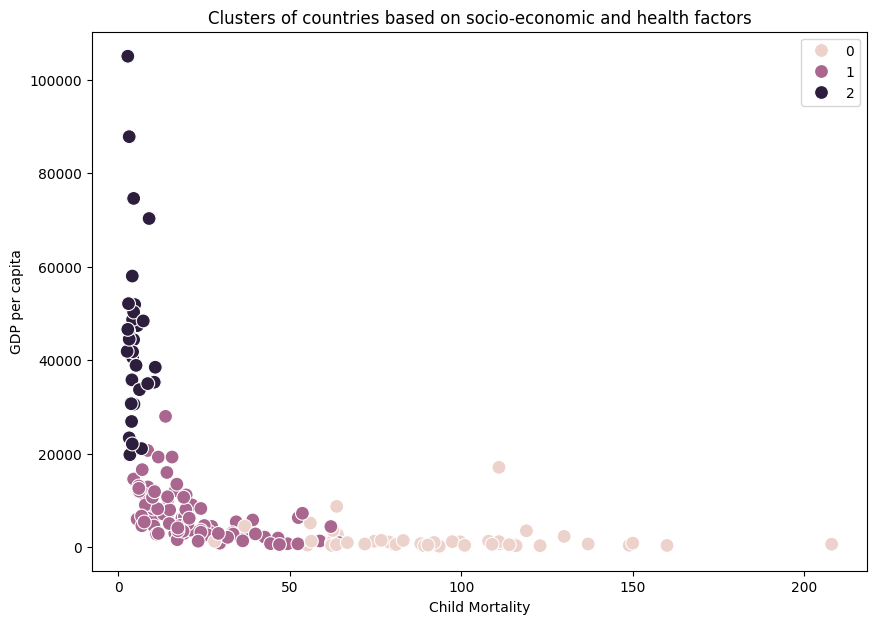

In [17]:
# Visualisation of clusters: child mortality vs gdpp

plt.figure(figsize=(10, 7))
sns.scatterplot(x='child_mort', y='gdpp', data=df, hue=kmeans.labels_, s=100)
plt.title('Clusters of countries based on socio-economic and health factors')
plt.xlabel('Child Mortality')
plt.ylabel('GDP per capita')
plt.show()

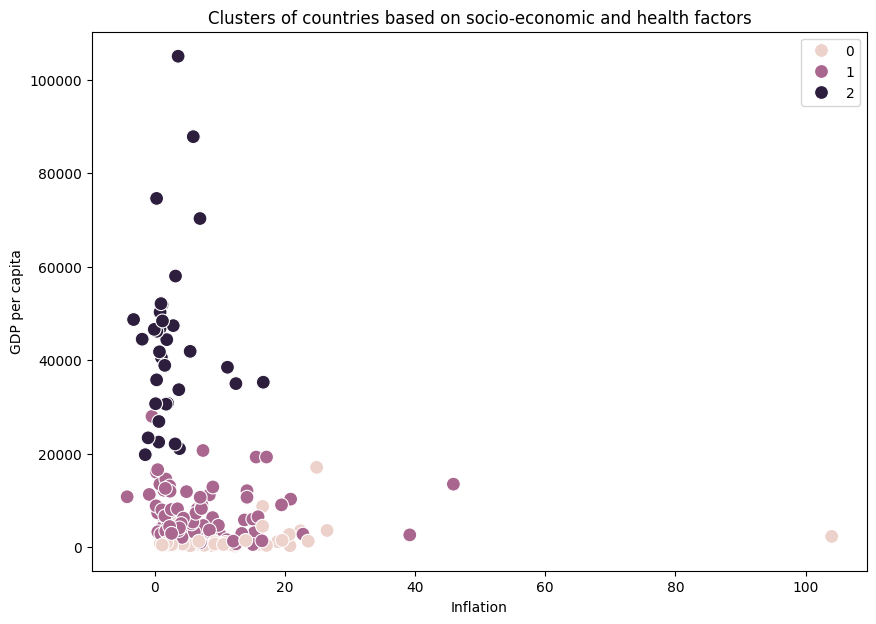

In [18]:
# Visualisation of clusters: inflation vs gdpp

plt.figure(figsize=(10, 7))
sns.scatterplot(x='inflation', y='gdpp', data=df, hue=kmeans.labels_, s=100)
plt.title('Clusters of countries based on socio-economic and health factors')
plt.xlabel('Inflation')
plt.ylabel('GDP per capita')
plt.show()

## Conclusions

Label the groups of countries in the plots you created based on child mortality, GDPP and inflation. You may use [terms](https://en.wikipedia.org/wiki/Developing_country#Terms_used_to_classify_countries) such as: least developed, developing and developed, or low, low-middle, upper-middle and high income. Alternatively, simply rank them from highest to lowest. Justify the labels you assign to each group.


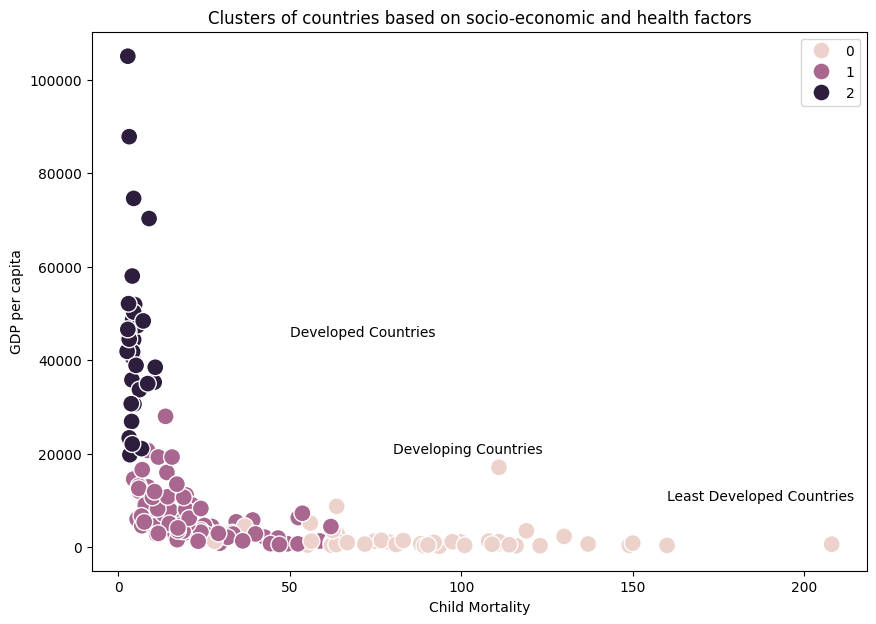

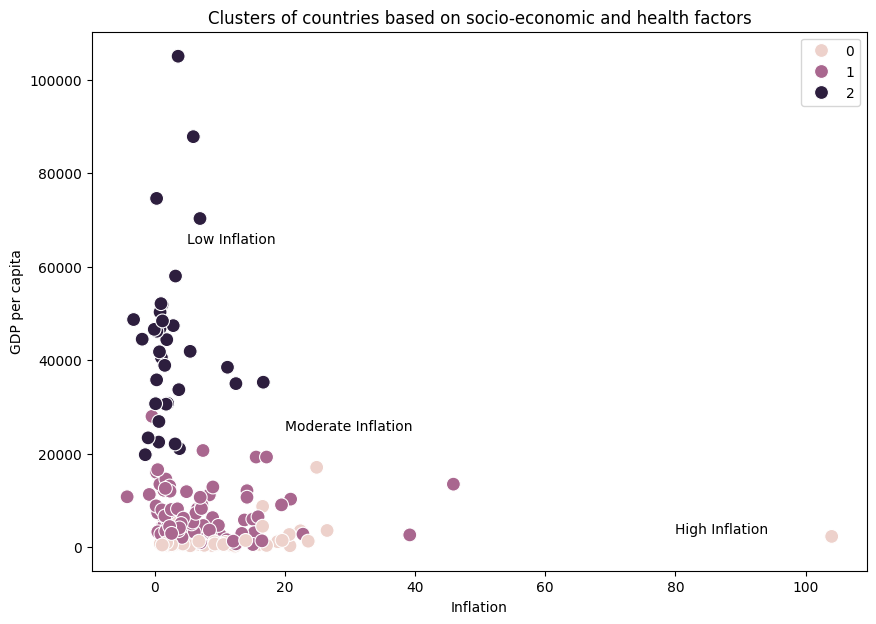

In [79]:
# Label the groups of countries in the plot based on child mortality and GDPP

plt.figure(figsize=(10, 7))
sns.scatterplot(x='child_mort', y='gdpp', data=df, hue=kmeans.labels_, s=150)

# Add labels to the clusters

plt.text(x=50, y=45000, s='Developed Countries')
plt.text(x=80, y=20000, s='Developing Countries')
plt.text(x=160, y=10000, s='Least Developed Countries')

plt.title('Clusters of countries based on socio-economic and health factors')
plt.xlabel('Child Mortality')
plt.ylabel('GDP per capita')
plt.show()

# Label the groups of countries in the plot based on inflation and GDPP

plt.figure(figsize=(10, 7))
sns.scatterplot(x='inflation', y='gdpp', data=df, hue=kmeans.labels_, s=100)

# Add labels to the clusters

plt.text(x=5, y=65000, s='Low Inflation')
plt.text(x=20, y=25000, s='Moderate Inflation')
plt.text(x=80, y=3000, s='High Inflation')

plt.title('Clusters of countries based on socio-economic and health factors')
plt.xlabel('Inflation')
plt.ylabel('GDP per capita')
plt.show()

**Answer here:**


# Justification

# The labels assigned to each group are based on the following criteria:

# - **Child mortality:** The countries in the cluster with the highest child mortality rate are labeled as "Least Developed Countries". The countries in the cluster with the lowest child mortality rate are labeled as "Developed Countries". The countries in the cluster with a child mortality rate in between the other two clusters are labeled as "Developing Countries".
# - **GDPP:** The countries in the cluster with the highest GDPP are labeled as "High Income Countries". The countries in the cluster with the lowest GDPP are labeled as "Low Income Countries". The countries in the cluster with a GDPP in between the other two clusters are labeled as "Middle Income Countries".
# - **Inflation:** The countries in the cluster with the lowest inflation rate are labeled as "Low Inflation". The countries in the cluster with the highest inflation rate are labeled as "High Inflation". The countries in the cluster with an inflation rate in between the other two clusters are labeled as "Moderate Inflation".

